## **Activity 3**

In [25]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# For reproducible results
tf.random.set_seed(42)
np.random.seed(42)

## **Load Dataset**

In [26]:
dataset_path = "/Users/leonmarco/Downloads/Dataset"
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Load full dataset with 80/20 train-val split
full_train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=42,
    label_mode="int"
)

x_val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=42,
    label_mode="int"
)

class_names = full_train_ds.class_names
NUM_CLASSES = len(class_names)
print("Classes:", class_names)

# Normalize pixel values from 0-255 to 0-1
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = full_train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = x_val_ds.map(lambda x, y: (normalization_layer(x), y))

print("Training batches:", len(train_ds))
print("Validation batches:", len(val_ds))

Found 535 files belonging to 3 classes.


Using 428 files for training.
Found 535 files belonging to 3 classes.
Using 107 files for validation.
Classes: ['Improperly Wearing Facemask', 'Not Wearing Facemask', 'Wearing Facemask']
Training batches: 14
Validation batches: 4


In [27]:
# (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# # Normalize pixel values from 0-255 to 0-1
# x_train = x_train.astype("float32") / 255.0
# x_test = x_test.astype("float32") / 255.0

# # Use smaller dataset for faster classroom demo
# x_train_small = x_train[:5000]
# y_train_small = y_train[:5000]
# x_val = x_train[5000:7000]
# y_val = y_train[5000:7000]
# print("Training data shape:", x_train_small.shape)
# print("Validation data shape:", x_val.shape)
# print("Test data shape:", x_test.shape)

## **Before Model**

In [28]:
before_model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Flatten(),
    layers.Dense(16, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

before_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nTraining BEFORE model...")
before_history = before_model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    verbose=1
)


Training BEFORE model...
Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 441ms/step - accuracy: 0.3248 - loss: 1.1248 - val_accuracy: 0.4486 - val_loss: 1.0538
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 426ms/step - accuracy: 0.4299 - loss: 1.0643 - val_accuracy: 0.4579 - val_loss: 1.0384
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 499ms/step - accuracy: 0.4673 - loss: 1.0370 - val_accuracy: 0.5234 - val_loss: 0.9896
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 521ms/step - accuracy: 0.5117 - loss: 1.0134 - val_accuracy: 0.5514 - val_loss: 0.9711
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 413ms/step - accuracy: 0.5234 - loss: 0.9910 - val_accuracy: 0.5888 - val_loss: 0.9558
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 416ms/step - accuracy: 0.5397 - loss: 0.9743 - val_accuracy: 0.5794 - val_loss: 0.9423
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 441ms/step - accuracy: 0.5491 - loss: 0.9572 - val_accuracy: 0.5514 - val_loss: 0.9358
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 458ms/step - accuracy: 0.5771 - loss:

In [29]:
# before_model = models.Sequential([
#     layers.Input(shape=(28, 28)),
#     layers.Flatten(),
#     layers.Dense(16, activation="relu"),
#     layers.Dense(10, activation="softmax")
# ])

# before_model.compile(
#     optimizer=tf.keras.optimizers.SGD(learning_rate=0.0001),
#     loss="sparse_categorical_crossentropy",
#     metrics=["accuracy"]
# )

# print("\nTraining BEFORE model...")
# before_history = before_model.fit(
#     x_train_small,
#     y_train_small,
#     epochs=10,
#     batch_size=32,
#     validation_data=(x_val, y_val),
#     verbose=1
# )

## **After Model**

In [30]:
after_model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

after_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nTraining AFTER model...")
after_history = after_model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    verbose=1
)


Training AFTER model...
Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 510ms/step - accuracy: 0.4229 - loss: 8.0604 - val_accuracy: 0.5327 - val_loss: 4.4470
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 448ms/step - accuracy: 0.5374 - loss: 3.0413 - val_accuracy: 0.5421 - val_loss: 1.8425
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 453ms/step - accuracy: 0.6519 - loss: 1.0359 - val_accuracy: 0.5140 - val_loss: 1.8545
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 454ms/step - accuracy: 0.6963 - loss: 1.0983 - val_accuracy: 0.5701 - val_loss: 1.6650
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 472ms/step - accuracy: 0.6145 - loss: 1.2329 - val_accuracy: 0.5140 - val_loss: 1.7890
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 445ms/step - accuracy: 0.5678 - loss: 1.8549 - val_accuracy: 0.4953 - val_loss: 2.6819
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 461ms/step - accuracy: 0.7009 - loss: 1.0149 - val_accuracy: 0.7009 - val_loss: 0.6321
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 440ms/step - accuracy: 0.8598 - loss: 

In [31]:
# after_model = models.Sequential([
#     layers.Input(shape=(28, 28)),
#     layers.Flatten(),
#     layers.Dense(128, activation="relu"),
#     layers.Dense(64, activation="relu"),
#     layers.Dense(10, activation="softmax")
# ])

# after_model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
#     loss="sparse_categorical_crossentropy",
#     metrics=["accuracy"]
# )

# print("\nTraining AFTER model...")
# after_history = after_model.fit(
#     x_train_small,
#     y_train_small,
#     epochs=10,
#     batch_size=32,
#     validation_data=(x_val, y_val),
#     verbose=1
# )

## **Evaluate Both Models**

In [32]:
before_test_loss, before_test_acc = before_model.evaluate(val_ds, verbose=0)
after_test_loss, after_test_acc = after_model.evaluate(val_ds, verbose=0)

print("\n================ RESULTS ================")
print(f"BEFORE Model Test Loss: {before_test_loss:.4f}")
print(f"BEFORE Model Test Accuracy: {before_test_acc:.4f}")

print(f"\nAFTER Model Test Loss: {after_test_loss:.4f}")
print(f"AFTER Model Test Accuracy: {after_test_acc:.4f}")


================ RESULTS ================
BEFORE Model Test Loss: 0.8978
BEFORE Model Test Accuracy: 0.6262

AFTER Model Test Loss: 0.5486
AFTER Model Test Accuracy: 0.7850


In [33]:
# before_test_loss, before_test_acc = before_model.evaluate(x_test, y_test,
# verbose=0)
# after_test_loss, after_test_acc = after_model.evaluate(x_test, y_test,
# verbose=0)

# print("\n================ RESULTS ================")
# print(f"BEFORE Model Test Loss: {before_test_loss:.4f}")
# print(f"BEFORE Model Test Accuracy: {before_test_acc:.4f}")

# print(f"\nAFTER Model Test Loss: {after_test_loss:.4f}")
# print(f"AFTER Model Test Accuracy: {after_test_acc:.4f}")

## **Plot Training Accuracy**

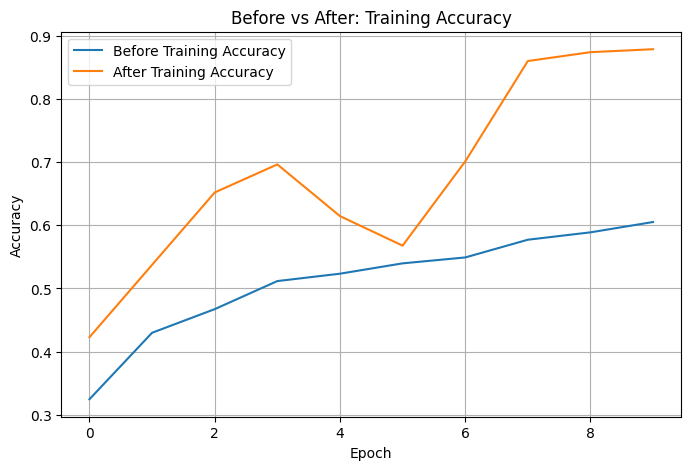

In [34]:
plt.figure(figsize=(8, 5))
plt.plot(before_history.history["accuracy"], label="Before Training Accuracy")
plt.plot(after_history.history["accuracy"], label="After Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Before vs After: Training Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## **Plot Validation Accuracy**

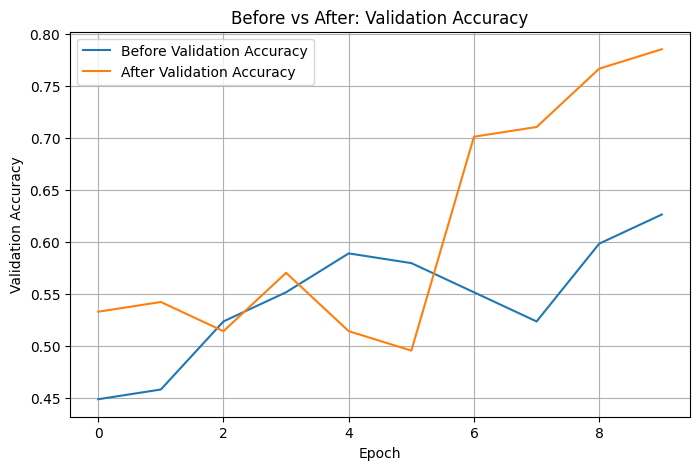

In [35]:
plt.figure(figsize=(8, 5))
plt.plot(before_history.history["val_accuracy"], label="Before Validation Accuracy")
plt.plot(after_history.history["val_accuracy"], label="After Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Before vs After: Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## **Plot Training Loss**

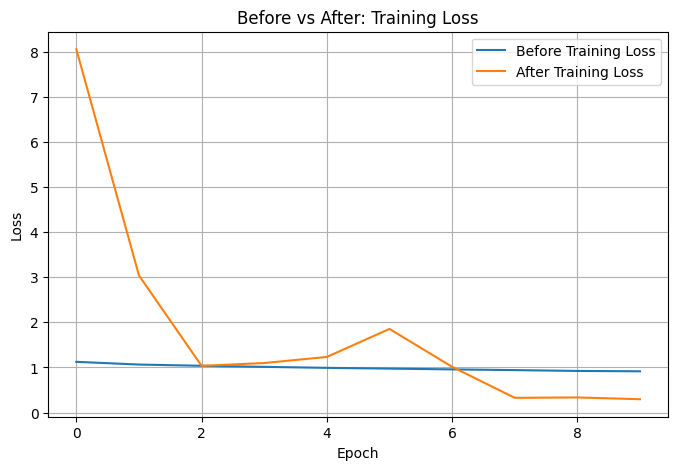

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(before_history.history["loss"], label="Before Training Loss")
plt.plot(after_history.history["loss"], label="After Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Before vs After: Training Loss")
plt.legend()
plt.grid(True)
plt.show()

## **Summary Table**

In [37]:
print("\n============== SUMMARY TABLE ==============")
print("Model\t\tOptimizer\tLearning Rate\tTest Accuracy")
print(f"Before\t\tSGD\t\t0.0001\t\t{before_test_acc:.4f}")
print(f"After\t\tAdam\t\t0.001\t\t{after_test_acc:.4f}")


============== SUMMARY TABLE ==============
Model		Optimizer	Learning Rate	Test Accuracy
Before		SGD		0.0001		0.6262
After		Adam		0.001		0.7850
